# 资金净流入 (netinflow) — 国家队注入模拟

---

## 1. 因子定义 (Wind 口径)

| 项目 | 内容 |
|------|------|
| **Wind 字段** | `f_mf_netinflow` |
| **中文名** | 净流入额 |
| **单位** | 元 (数据中为万元) |
| **算法** | `净流入额 = (当日场内流通份额 − 前一日场内流通份额) × 当日成交均价` |
| **来源** | Wind 计算 |

> **核心含义**: 衡量通过一级市场申购/赎回导致的 ETF 场内份额净增减对应的金额。正值代表有新资金通过申购进入。

---

## 2. 国家队操作影响分析

### 场内买入 → 对 netinflow **无直接影响**
- 场内买入是在二级市场（交易所）上买卖已有份额
- 份额只是从卖方转移到买方，**场内流通份额总量不变**
- 因此 `当日份额 − 前日份额 = 0`，netinflow 不受影响

### 场外申购 → **T+2** 影响 netinflow
- 国家队向基金公司提交 ETF 申购（一级市场），缴纳一篮子股票 + 现金
- ETF 申购流程：T 日提交申购 → T+1 日确认 → **T+2 日份额到账并进入场内流通**
- 到账当日：`场内流通份额增加` → `netinflow = Δ份额 × 当日均价 ≈ 申购金额`

| 操作类型 | 是否影响 | 生效时间 | 原因 |
|---------|---------|---------|------|
| 场内买入 | **否** | — | 份额在持有人间转移，流通总量不变 |
| 场外申购 | **是** | **T+2** | 新创建份额 T+2 到账，流通份额增加 |

---

## 3. Δ 计算公式

```text
Δnetinflow = 申购金额 (万元)
```

**推导**: 申购金额 X 万元 → 新增份额 = X / NAV → netinflow = 新增份额 × 均价 ≈ X（因为均价 ≈ NAV）

---

## 4. 模拟 Pipeline

```text
原始值 (raw) → 注入 delta 到 T+2 日 → Rolling Z-Score (窗口120, 最小60) → 相对因子 = z(A) − z(B)
```

---

## 5. 参数说明

| 参数 | 含义 | 影响 |
|------|------|------|
| `AUM_A / AUM_B` | ETF 资产管理规模 (亿元) | 决定买入金额按持仓市值比例分配 |
| `HOLD_PCT_A / HOLD_PCT_B` | 国家队持有比例 | 持仓价值 = HOLD_PCT × AUM，按比例分配总买入额 |
| `BUY_OFF_EXCHANGE` | 场外申购总额 (亿元) | 直接决定 delta 大小 |
| `BUY_ON_EXCHANGE` | 场内买入总额 (亿元) | 对本因子无影响，设为 0 |

---

## 6. 对大盘减小盘风格（y）的预期影响时间

> `y = 上证50日收益率 − 上证1000日收益率`。本因子作为**预测信号**，通过捕捉国家队资金偏好差异，预测大盘相对小盘的超额表现。

| 路径 | 预期影响时间 | 说明 |
|------|------------|------|
| 场外申购 → 通过本因子信号 | **T+2 ~ T+5** | 因子在T+2（份额到账日）生效，叠加回归预测滞后 0–3 期 |
| 场内买入 → 直接价格冲击 | **T+0** | 场内买入当日推高大盘ETF价格，但不影响本因子，仅为直接价格效应 |

> **结论**: 国家队 T+0 出手 → 直接价格效应当日体现；通过本因子的信号传导，预期影响 y 的时间窗口见上表。


In [13]:
# ══════════════ 参数设置 (修改这里) ══════════════

# ── ETF 代码 ──
CODE_A = "510050.SH"          # 大 ETF
CODE_B = "510100.SH"          # 小 ETF

# ── ETF 基础参数 (影响 delta 计算, 可根据实际值调整) ──
NAME_A  = "华夏上证50ETF"      # ETF A 名称
NAME_B  = "易方达上证50ETF"    # ETF B 名称
AUM_A   = 1750                # ETF A 资产管理规模 (亿元)
AUM_B   = 46                  # ETF B 资产管理规模 (亿元)
NAV_A   = 3.09                # ETF A 单位净值 (元/份)
NAV_B   = 2.93                # ETF B 单位净值 (元/份)
SHARES_A = 5_670_000          # ETF A 总份额 (万份)
SHARES_B = 157_000            # ETF B 总份额 (万份)
DAILY_AMT_A = 200_000         # ETF A 日均成交额 (万元)
DAILY_AMT_B = 50_000          # ETF B 日均成交额 (万元)

# ── 模拟设置 ──
SIM_DATE = "2024-09-24"       # 注入日期 (T+0)
HOLD_PCT_A = 0.70             # 国家队持有大ETF份额占比
HOLD_PCT_B = 0.30             # 国家队持有小ETF份额占比

BUY_ON_EXCHANGE  = 30.0        # 场内买入 (亿元) — 对netinflow无直接影响
BUY_OFF_EXCHANGE = 30.0       # 场外申购 (亿元) — T+2影响netinflow

ZOOM_HALF = 30                # 显示注入日前后多少个交易日

In [14]:
import datetime
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))
sys.path.insert(0, ".")
from sim_utils import *

setup_style()

SHEET = "netinflow"
UNIT = "万元"
LAG = 2  # T+2

sim_date = datetime.datetime.strptime(SIM_DATE, "%Y-%m-%d").date()

off_a, off_b = buy_split(BUY_OFF_EXCHANGE, AUM_A, AUM_B, HOLD_PCT_A, HOLD_PCT_B)

print(f"ETF对: {NAME_A} ({CODE_A}) vs {NAME_B} ({CODE_B})")
print(f"  AUM: {AUM_A}亿 vs {AUM_B}亿 | NAV: {NAV_A}元 vs {NAV_B}元")
print(f"场外申购: {BUY_OFF_EXCHANGE}亿 → {NAME_A} {off_a:.2f}亿, {NAME_B} {off_b:.2f}亿")

delta_a = off_a * 10000  # 亿→万
delta_b = off_b * 10000
print(f"\nΔ netinflow:")
print(f"  {CODE_A}: +{delta_a:,.0f} {UNIT}")
print(f"  {CODE_B}: +{delta_b:,.0f} {UNIT}")

ETF对: 华夏上证50ETF (510050.SH) vs 易方达上证50ETF (510100.SH)
  AUM: 1750亿 vs 46亿 | NAV: 3.09元 vs 2.93元
场外申购: 30.0亿 → 华夏上证50ETF 29.67亿, 易方达上证50ETF 0.33亿

Δ netinflow:
  510050.SH: +296,658 万元
  510100.SH: +3,342 万元


In [15]:
# 加载数据
sheets_raw = load_raw()
df_y = load_y()
df_orig = sheets_raw[SHEET]

all_dates = sorted(df_orig[DATE_COL].dropna().unique())
t2 = offset_date(all_dates, sim_date, LAG)
t1 = offset_date(all_dates, sim_date, 1)
print(f"T+0 = {sim_date},  T+1 = {t1},  T+2 = {t2} (生效日)")

# 注入
df_mod = df_orig.copy()
df_mod = inject_one(df_mod, t2, CODE_A, delta_a)
df_mod = inject_one(df_mod, t2, CODE_B, delta_b)

z_before = zscore_sheet(df_orig)
z_after  = zscore_sheet(df_mod)
rel_before = relative_factor(z_before, CODE_A, CODE_B)
rel_after  = relative_factor(z_after, CODE_A, CODE_B)

zoom = zoom_range(all_dates, sim_date, ZOOM_HALF)
mask = df_orig[DATE_COL].isin(zoom)
dates = list(df_orig.loc[mask, DATE_COL])

T+0 = 2024-09-24,  T+1 = 2024-09-25,  T+2 = 2024-09-26 (生效日)


In [16]:
import importlib, sim_utils; importlib.reload(sim_utils); from sim_utils import *

print_detail(df_orig, df_mod, z_before, z_after,
             CODE_A, CODE_B, NAME_A, NAME_B, UNIT,
             sim_date, all_dates, effect_date=t2, half=5)


  华夏上证50ETF (510050.SH)  —  单位: 万元
          日期 |      raw_bef      raw_aft |   mean_bef   mean_aft |    std_bef    std_aft |   z_bef   z_aft      Δz |
-------------------------------------------------------------------------------------------------------------------
  2024-09-13 |       -3,107       -3,107 |     26,368     26,368 |     97,501     97,501 |  -0.302  -0.302  +0.000 |
  2024-09-18 |      -32,742      -32,742 |     27,288     27,288 |     96,532     96,532 |  -0.622  -0.622  +0.000 |
  2024-09-19 |      -16,639      -16,639 |     28,157     28,157 |     95,769     95,769 |  -0.468  -0.468  +0.000 |
  2024-09-20 |       97,721       97,721 |     29,800     29,800 |     95,679     95,679 |   0.710   0.710  +0.000 |
  2024-09-23 |        1,050        1,050 |     30,426     30,426 |     95,300     95,300 |  -0.308  -0.308  +0.000 |
  2024-09-24 |     -158,101     -158,101 |     29,625     29,625 |     96,584     96,584 |  -1.944  -1.944  +0.000 | ★T+0
  2024-09-25 |      -51,

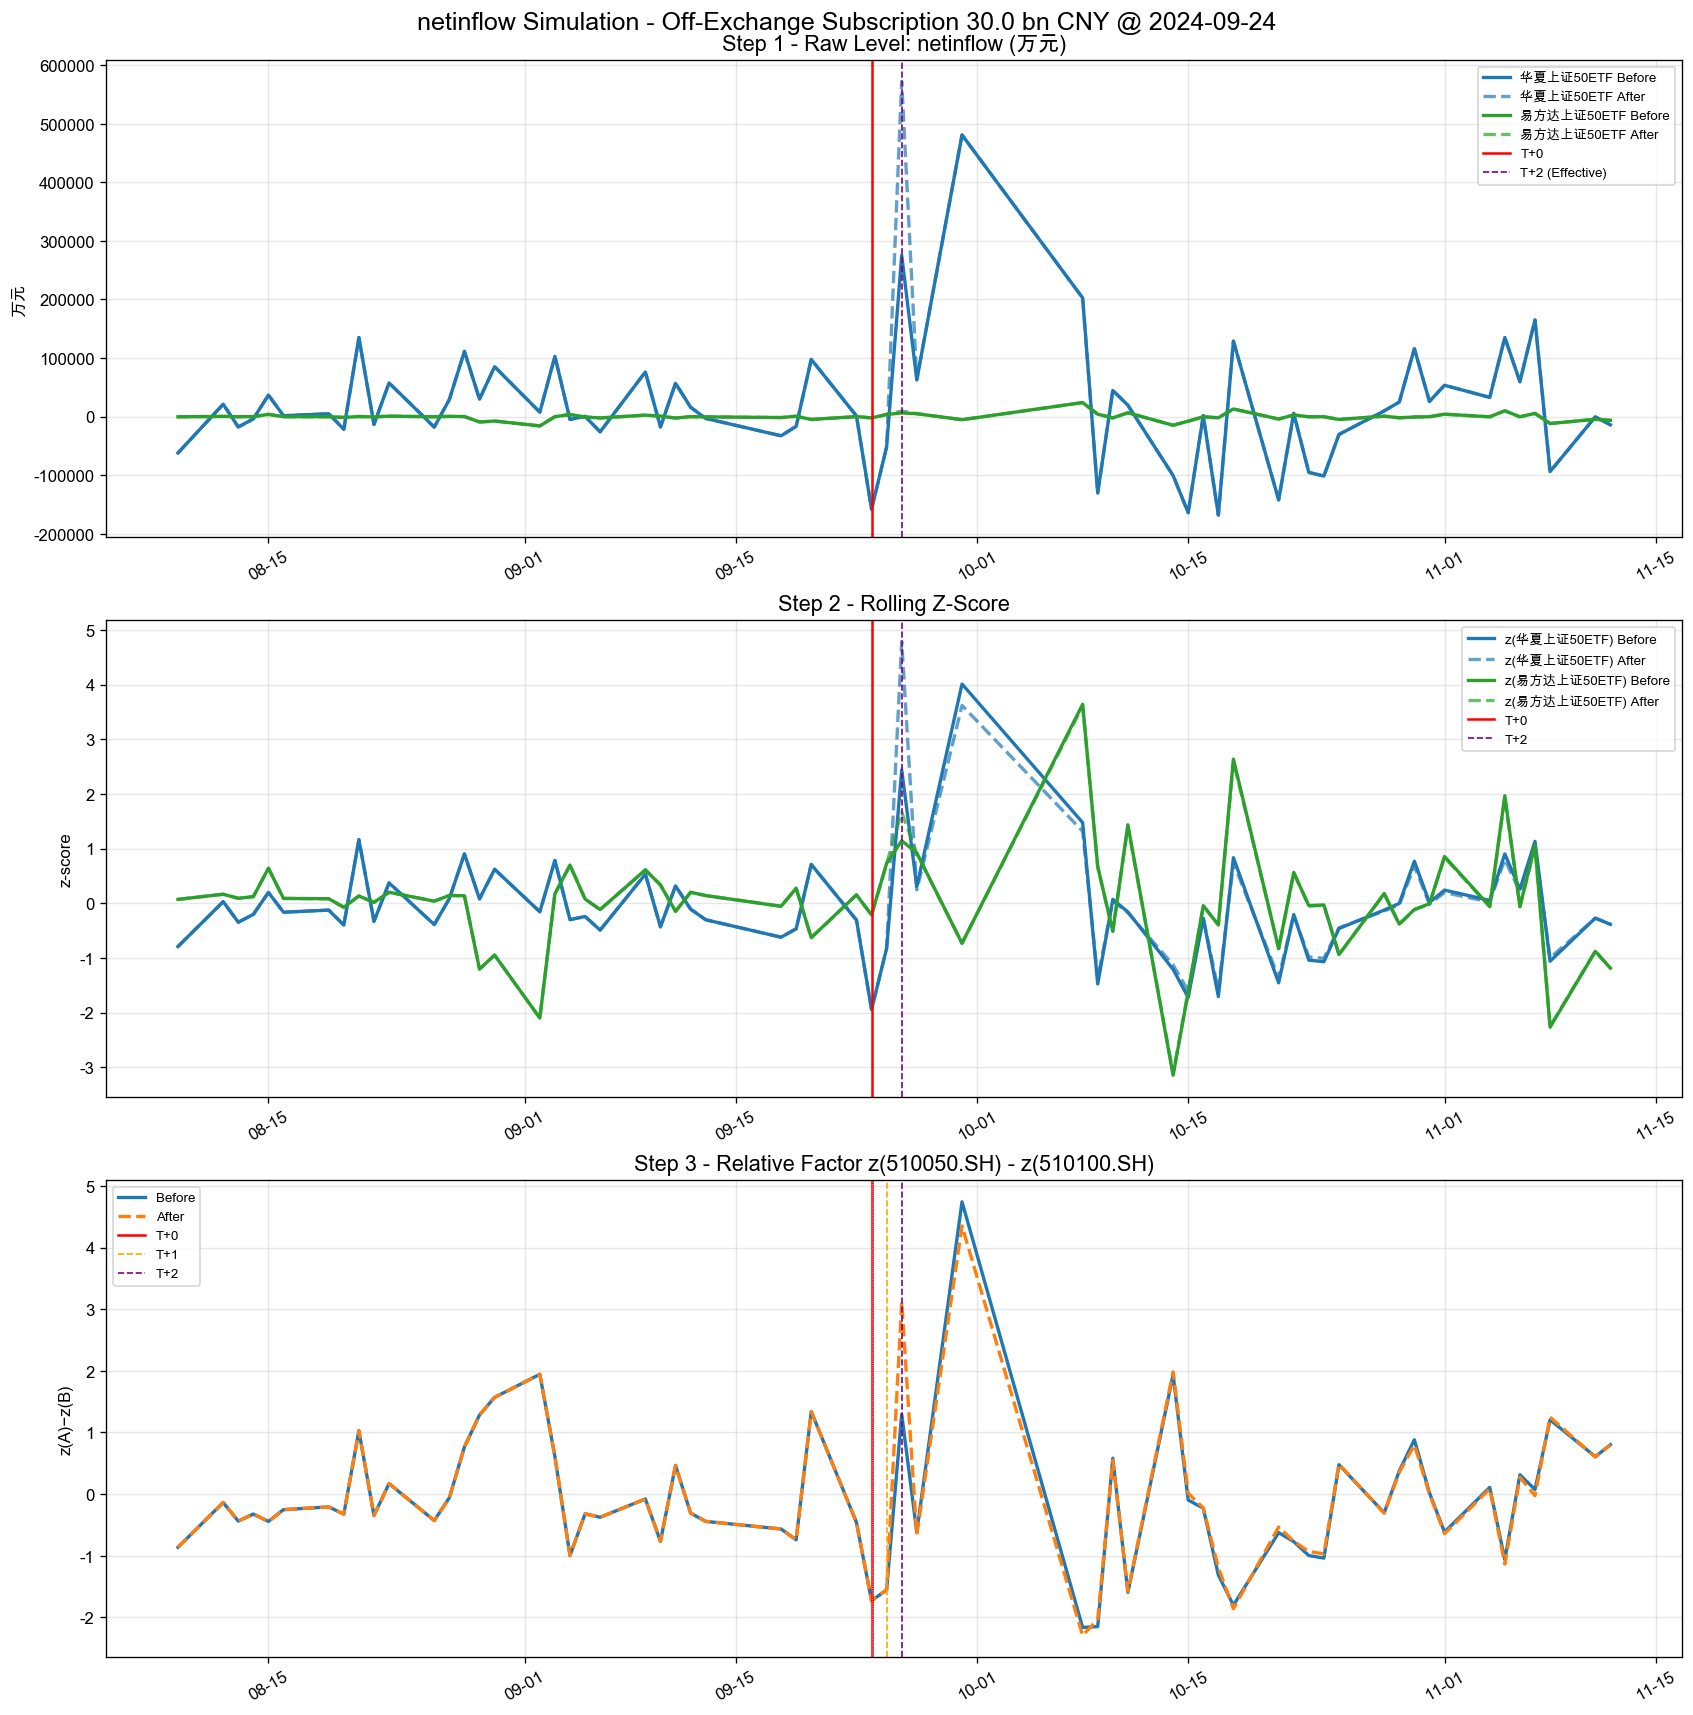

In [17]:
import pandas as pd

fig, axes = plt.subplots(3, 1, figsize=(14, 14), constrained_layout=True)

# Step 1: 原始值
for code, label, c in [(CODE_A, NAME_A, '#1f77b4'), (CODE_B, NAME_B, '#2ca02c')]:
    before_v = pd.to_numeric(df_orig.loc[mask, code], errors='coerce').tolist()
    after_v  = pd.to_numeric(df_mod.loc[mask, code], errors='coerce').tolist()
    axes[0].plot(dates, before_v, label=f'{label} Before', color=c, lw=2)
    axes[0].plot(dates, after_v,  label=f'{label} After', color=c, lw=2, ls='--', alpha=0.7)
axes[0].axvline(sim_date, color='red', lw=1.5, label='T+0')
if t2 in zoom: axes[0].axvline(t2, color='purple', lw=1, ls='--', label='T+2 (Effective)')
axes[0].set_title(f'Step 1 - Raw Level: netinflow ({UNIT})', fontsize=13)
axes[0].set_ylabel(UNIT)
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[0].tick_params(axis='x', rotation=30)

# Step 2: Z-Score
for code, label, c in [(CODE_A, NAME_A, '#1f77b4'), (CODE_B, NAME_B, '#2ca02c')]:
    axes[1].plot(dates, z_before.loc[mask, code].tolist(), label=f'z({label}) Before', color=c, lw=2)
    axes[1].plot(dates, z_after.loc[mask, code].tolist(),  label=f'z({label}) After', color=c, lw=2, ls='--', alpha=0.7)
axes[1].axvline(sim_date, color='red', lw=1.5, label='T+0')
if t2 in zoom: axes[1].axvline(t2, color='purple', lw=1, ls='--', label='T+2')
axes[1].set_title('Step 2 - Rolling Z-Score', fontsize=13)
axes[1].set_ylabel('z-score')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[1].tick_params(axis='x', rotation=30)

# Step 3: 相对因子
plot_ba(axes[2], dates,
        rel_before[mask].tolist(), rel_after[mask].tolist(),
        f'Step 3 - Relative Factor z({CODE_A}) - z({CODE_B})',
        'z(A)−z(B)', sim_date, t1, t2)

plt.suptitle(f'netinflow Simulation - Off-Exchange Subscription {BUY_OFF_EXCHANGE} bn CNY @ {SIM_DATE}', fontsize=15, y=1.01)
plt.show()